In [3]:
# Run once to install required libraries
!pip install requests pandas tqdm

In [4]:
import requests
import pandas as pd
import time
import re
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
EMAIL = "laminefaye0710@gmail.com"

PUBMED_BASE        = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
TARGET_PER_CATEGORY = 220   # fetch a few extra; we'll cap at 200 after filtering
WORD_LIMIT         = 100    # words per record for the trimmed file
SLEEP_BETWEEN_REQS = 0.4    # stay within NCBI's 3 req/s guideline

# ── Category definitions ──────────────────────────────────────────────────────
CATEGORIES = {
    "a": {
        "label": "Alzheimers",
        "query": "Alzheimer's disease machine learning OR deep learning OR NLP[Title/Abstract]",
    },
    "b": {
        "label": "Parkinsons",
        "query": "Parkinson's disease machine learning OR deep learning OR NLP[Title/Abstract]",
    },
    "c": {
        "label": "Dementia",
        "query": "dementia vascular OR frontotemporal machine learning OR NLP[Title/Abstract]",
    },
    "d": {
        "label": "ALS",
        "query": "amyotrophic lateral sclerosis ALS machine learning OR deep learning[Title/Abstract]",
    },
    "e": {
        "label": "Huntingtons",
        "query": "Huntington's disease machine learning OR deep learning OR biomarker[Title/Abstract]",
    },
}

print(f"   Target records per category : {TARGET_PER_CATEGORY}")
print(f"   Word limit per record       : {WORD_LIMIT}")
print(f"   Categories                  : {list(CATEGORIES.keys())}")

   Target records per category : 220
   Word limit per record       : 100
   Categories                  : ['a', 'b', 'c', 'd', 'e']


In [9]:
# ── Helper Functions ────────────────────────────────────────────────────────────────

def search_pubmed(query: str, max_results: int) -> list:
    """Return a list of PubMed IDs matching the query."""
    params = {
        "db": "pubmed",
        "term": query,
        "retmax": max_results,
        "retmode": "json",
        "tool": "dsa_group_assignment",
        "email": EMAIL,
    }
    r = requests.get(f"{PUBMED_BASE}/esearch.fcgi", params=params, timeout=15)
    r.raise_for_status()
    return r.json()["esearchresult"]["idlist"]


def fetch_abstracts(pmids: list) -> list:
    """Fetch titles + abstracts for a list of PubMed IDs (batched 100 at a time)."""
    records = []
    batch_size = 100

    for i in tqdm(range(0, len(pmids), batch_size), desc="  Fetching batches", leave=False):
        batch = pmids[i : i + batch_size]
        params = {
            "db": "pubmed",
            "id": ",".join(batch),
            "retmode": "xml",
            "rettype": "abstract",
            "tool": "dsa_group_assignment",
            "email": EMAIL,
        }
        r = requests.get(f"{PUBMED_BASE}/efetch.fcgi", params=params, timeout=30)
        r.raise_for_status()
        records.extend(parse_xml(r.text))
        time.sleep(SLEEP_BETWEEN_REQS)

    return records


def parse_xml(xml_text: str) -> list:
    """Extract PMID, title, and abstract from PubMed XML response.
    
    Handles both simple abstracts (<AbstractText>text</AbstractText>)
    and structured abstracts with multiple labelled sections
    (<AbstractText Label='BACKGROUND'>...</AbstractText> etc.)
    """
    results = []
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError:
        return results

    for article in root.findall(".//PubmedArticle"):
        pmid_el  = article.find(".//PMID")
        title_el = article.find(".//ArticleTitle")

        pmid  = pmid_el.text.strip()  if (pmid_el  is not None and pmid_el.text)  else ""
        title = title_el.text.strip() if (title_el is not None and title_el.text) else ""

        # Collect ALL <AbstractText> nodes and join — handles structured abstracts
        abstract_parts = []
        for ab_el in article.findall(".//AbstractText"):
            # ET itertext() safely collects text + tail from nested tags
            part = "".join(ab_el.itertext()).strip()
            if part:
                abstract_parts.append(part)
        abstract = " ".join(abstract_parts)

        # skip records with no / very short abstract
        if not abstract or len(abstract.split()) < 30:
            continue

        results.append({"pmid": pmid, "title": title, "abstract": abstract})

    return results


def clean_text(text: str) -> str:
    """Strip stray HTML/XML tags and collapse whitespace."""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def trim_to_n_words(text: str, n: int = WORD_LIMIT) -> str:
    """Return first n words of text."""
    return " ".join(text.split()[:n])


In [10]:
# ─ Main data collection loop ─────────────────────────────────────────────────
all_rows = []

for code, info in CATEGORIES.items():
    print(f"\n{'='*60}")
    print(f"Category [{code}] — {info['label']}")
    print(f"Query: {info['query']}")
    print(f"{'='*60}")

    # Step 1: search for PMIDs
    pmids = search_pubmed(info["query"], max_results=TARGET_PER_CATEGORY)
    print(f"  Found {len(pmids)} PubMed IDs")

    # Step 2: fetch full abstracts
    records = fetch_abstracts(pmids)
    print(f"  Parsed {len(records)} records with usable abstracts (≥30 words)")

    # Step 3: cap at 200
    records = records[:200]

    for rec in records:
        all_rows.append({
            "pmid"    : rec["pmid"],
            "label"   : code,                         # a / b / c / d / e
            "category": info["label"],
            "title"   : clean_text(rec["title"]),
            "abstract": clean_text(rec["abstract"]),
            "text"    : clean_text(rec["title"] + " " + rec["abstract"]),
        })

    print(f"  ✓ Kept {len(records)} records for label '{code}'")
    time.sleep(1)  # be polite between category queries

print(f"\n{'='*60}")
print(f"Done! Total records collected: {len(all_rows)}")


Category [a] — Alzheimers
Query: Alzheimer's disease machine learning OR deep learning OR NLP[Title/Abstract]
  Found 220 PubMed IDs


  Fetching batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Parsed 215 records with usable abstracts (≥30 words)
  ✓ Kept 200 records for label 'a'

Category [b] — Parkinsons
Query: Parkinson's disease machine learning OR deep learning OR NLP[Title/Abstract]
  Found 220 PubMed IDs


  Fetching batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Parsed 215 records with usable abstracts (≥30 words)
  ✓ Kept 200 records for label 'b'

Category [c] — Dementia
Query: dementia vascular OR frontotemporal machine learning OR NLP[Title/Abstract]
  Found 220 PubMed IDs


...

  Parsed 218 records with usable abstracts (≥30 words)
  ✓ Kept 200 records for label 'c'

Category [d] — ALS
Query: amyotrophic lateral sclerosis ALS machine learning OR deep learning[Title/Abstract]
  Found 220 PubMed IDs


  Fetching batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Parsed 214 records with usable abstracts (≥30 words)
  ✓ Kept 200 records for label 'd'

Category [e] — Huntingtons
Query: Huntington's disease machine learning OR deep learning OR biomarker[Title/Abstract]
  Found 220 PubMed IDs


  Fetching batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Parsed 215 records with usable abstracts (≥30 words)
  ✓ Kept 200 records for label 'e'

Done! Total records collected: 1000


In [11]:
# ── Raw CSV (full abstracts) ───────────────────────────────────────────────────
df_raw = pd.DataFrame(all_rows)
df_raw.to_csv("neuro_abstracts_raw.csv", index=False)
print(f"Saved neuro_abstracts_raw.csv ({len(df_raw)} records)")

# ── Trimmed CSV (~100 words per record, as per assignment spec) ───────────────
df_trim = df_raw.copy()
df_trim["text"] = df_trim["text"].apply(lambda t: trim_to_n_words(t, WORD_LIMIT))
df_trim.to_csv("neuro_abstracts_100w.csv", index=False)
print(f"Saved neuro_abstracts_100w.csv ({len(df_trim)} records, ~{WORD_LIMIT} words each)")

Saved neuro_abstracts_raw.csv (1000 records)
Saved neuro_abstracts_100w.csv (1000 records, ~100 words each)


In [12]:
# ── Explore the data─────────────────────────────────────────────────────────
print("=== Shape ===")
print(f"Raw     : {df_raw.shape}")
print(f"Trimmed : {df_trim.shape}")

print("\n=== Class distribution ===")
dist = df_raw.groupby(["label", "category"]).size().reset_index(name="count")
print(dist.to_string(index=False))

=== Shape ===
Raw     : (1000, 6)
Trimmed : (1000, 6)

=== Class distribution ===
label    category  count
    a  Alzheimers    200
    b  Parkinsons    200
    c    Dementia    200
    d         ALS    200
    e Huntingtons    200


/tmp/ipykernel_6627/215840584.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=counts.index, patch_artist=True,


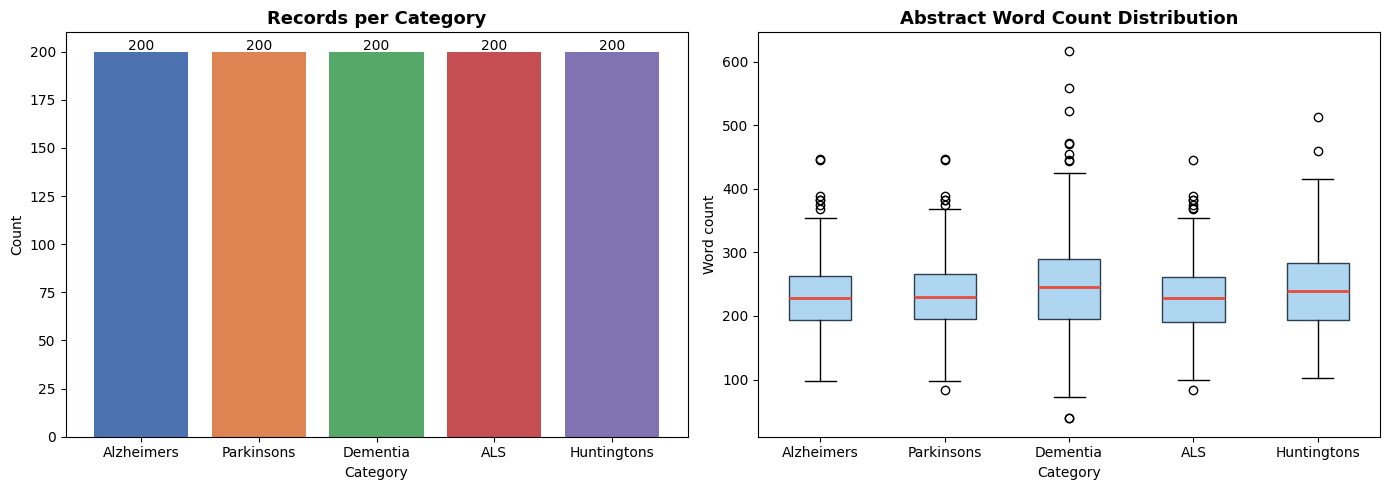

Plot saved as dataset_overview.png


In [13]:
import matplotlib.pyplot as plt

# ── Word count distribution per category ──────────────────────────────────────
df_raw["word_count"] = df_raw["abstract"].apply(lambda t: len(t.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: records per category
counts = df_raw["category"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"])
axes[0].set_title("Records per Category", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Category")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=10)

# Box: word count distribution
groups = [df_raw[df_raw["category"] == cat]["word_count"].values for cat in counts.index]
axes[1].boxplot(groups, labels=counts.index, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", color="#2C3E50"),
                medianprops=dict(color="#E74C3C", linewidth=2))
axes[1].set_title("Abstract Word Count Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Word count")
axes[1].set_xlabel("Category")

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as dataset_overview.png")

In [14]:
# ── Preview one record from each category ─────────────────────────────────────
print("=== Sample record from each category ===\n")
for code in sorted(df_trim["label"].unique()):
    row = df_trim[df_trim["label"] == code].iloc[0]
    print(f"[{code}] {row['category']}")
    print(f"  Title : {row['title'][:80]}...")
    print(f"  Text  : {row['text'][:120]}...")
    print(f"  Words : {len(row['text'].split())}")
    print()

=== Sample record from each category ===

[a] Alzheimers
  Title : Cross-domain evaluation and fine-tuned adaptation of iCatcher+ for Korean infant...
  Text  : Cross-domain evaluation and fine-tuned adaptation of iCatcher+ for Korean infant gaze data. This study evaluates the cro...
  Words : 100

[b] Parkinsons
  Title : Cross-domain evaluation and fine-tuned adaptation of iCatcher+ for Korean infant...
  Text  : Cross-domain evaluation and fine-tuned adaptation of iCatcher+ for Korean infant gaze data. This study evaluates the cro...
  Words : 100

[c] Dementia
  Title : Diagnostic Agreement and Prognostic Value of Clinically Interpreted CT vs MRI fo...
  Text  : Diagnostic Agreement and Prognostic Value of Clinically Interpreted CT vs MRI for Incidentally Discovered Covert Cerebro...
  Words : 100

[d] ALS
  Title : Cross-domain evaluation and fine-tuned adaptation of iCatcher+ for Korean infant...
  Text  : Cross-domain evaluation and fine-tuned adaptation of iCatcher+ for Korean 